<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/XP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/content/diabetes_prediction_dataset.csv


Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset (1).csv

 Fichier chargé avec succès !
Dimensions : (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

=== EXERCICE 1 : Exploration des données ===
Nombre total d'échantillons : 100000
Colonnes : ['gender', 'age', 'hypertension', 'heart_disease', 'smoki

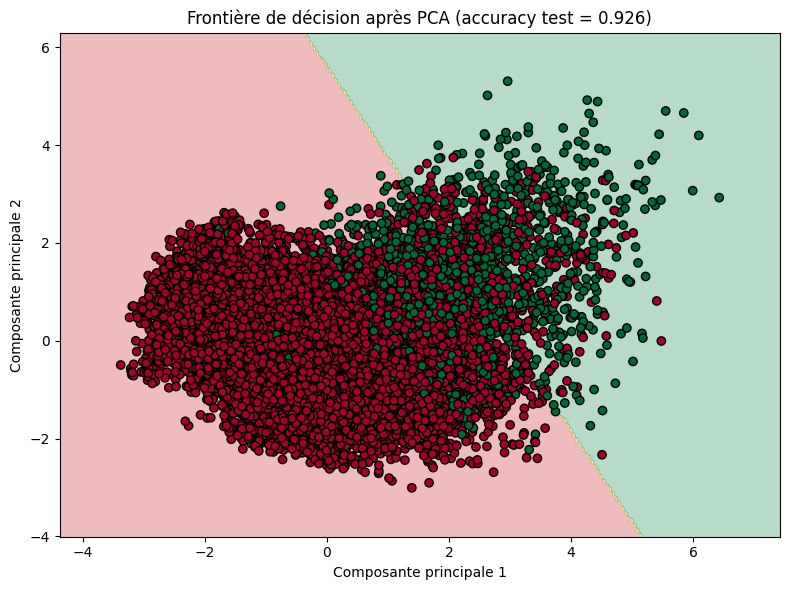

La frontière sépare les deux classes. Les points sont les individus du test set.

=== EXERCICE 6 : Courbe ROC et AUC ===


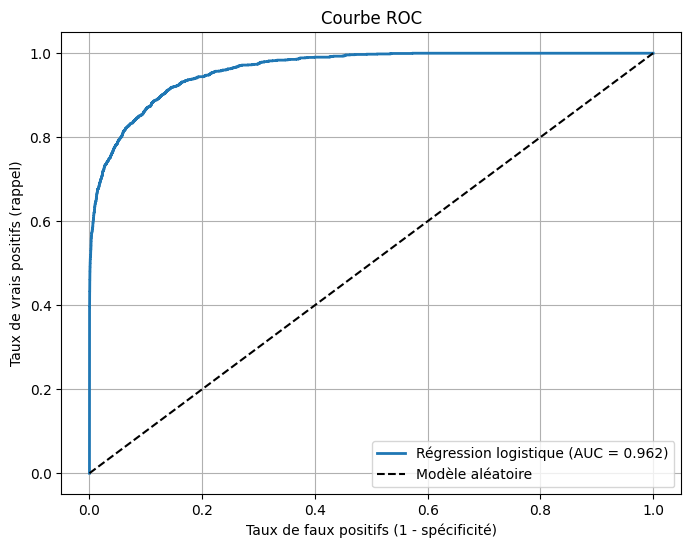

AUC = 0.962
Plus l'AUC est proche de 1, meilleur est le pouvoir discriminant du modèle.
Une AUC de 0.5 correspond à un modèle aléatoire.


In [2]:

# DIABETES PREDICTION - LOGISTIC REGRESSION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
from google.colab import files


# CHARGEMENT DU FICHIER CSV

print("/content/diabetes_prediction_dataset.csv")
uploaded = files.upload()

# Récupération du nom du fichier uploadé
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("\n Fichier chargé avec succès !")
print(f"Dimensions : {df.shape}")
print(df.head())


# EXERCICE 1 : Compréhension et collecte des données

print("\n=== EXERCICE 1 : Exploration des données ===")
print(f"Nombre total d'échantillons : {len(df)}")
print(f"Colonnes : {df.columns.tolist()}")

# Encodage des variables catégorielles (gender, smoking_history)
le_gender = LabelEncoder()
le_smoking = LabelEncoder()
df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['smoking_enc'] = le_smoking.fit_transform(df['smoking_history'])

# Sélection des features
features = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
            'blood_glucose_level', 'gender_enc', 'smoking_enc']
X = df[features]
y = df['diabetes']

print(f"Cas positifs (diabète) : {y.sum()}")
print(f"Cas négatifs (pas diabète) : {len(y)-y.sum()}")
print(f"Proportion de diabète : {y.mean():.2%}")

# Division train/test (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train : {X_train.shape[0]} échantillons, Test : {X_test.shape[0]} échantillons")


# EXERCICE 2 : Modèle et standardisation

print("\n=== EXERCICE 2 : Choix du modèle et standardisation ===")
print("Le problème est une classification binaire (diabète ou non).")
print("La régression logistique est adaptée : simple, rapide, interprétable.")

# Standardisation (car les features n'ont pas la même échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standardisation effectuée (moyenne=0, écart-type=1).")


# EXERCICE 3 : Entraînement du modèle

print("\n=== EXERCICE 3 : Entraînement ===")
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Modèle entraîné.")


# EXERCICE 4 : Évaluation (Accuracy, Matrice de confusion, Précision, Rappel, F1)

print("\n=== EXERCICE 4 : Métriques d'évaluation ===")
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Non diabète', 'Diabète'])

print(f"Accuracy : {accuracy:.4f}")
print("\nMatrice de confusion :")
print(conf)
print("\nRapport de classification :")
print(report)

# Commentaires
print("\nCommentaires :")
print(f"- L'accuracy de {accuracy:.2%} indique le taux de bonnes prédictions.")
print("- La matrice de confusion montre les VP, VN, FP, FN.")
print("- Le rappel (recall) pour la classe 'Diabète' est important pour ne pas manquer de vrais malades.")
print("- Le F1-score équilibre précision et rappel, utile en cas de déséquilibre.")


# EXERCICE 5 : Visualisation de la frontière de décision (avec PCA)

print("\n=== EXERCICE 5 : Frontière de décision ===")
# On réduit les données à 2 dimensions pour la visualisation
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Entraînement d'un modèle sur ces 2 composantes (juste pour l'affichage)
model_pca = LogisticRegression()
model_pca.fit(X_train_pca, y_train)
acc_pca = model_pca.score(X_test_pca, y_test)

# Tracé
def plot_decision_boundary(X, y, model, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlGn)
    ax.set_xlabel('Composante principale 1')
    ax.set_ylabel('Composante principale 2')

fig, ax = plt.subplots(figsize=(8,6))
plot_decision_boundary(X_test_pca, y_test, model_pca, ax)
ax.set_title(f"Frontière de décision après PCA (accuracy test = {acc_pca:.3f})")
plt.tight_layout()
plt.show()
print("La frontière sépare les deux classes. Les points sont les individus du test set.")


# EXERCICE 6 : Courbe ROC

print("\n=== EXERCICE 6 : Courbe ROC et AUC ===")
y_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Régression logistique (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire')
plt.xlabel('Taux de faux positifs (1 - spécificité)')
plt.ylabel('Taux de vrais positifs (rappel)')
plt.title('Courbe ROC')
plt.legend()
plt.grid(True)
plt.show()
print(f"AUC = {auc:.3f}")
print("Plus l'AUC est proche de 1, meilleur est le pouvoir discriminant du modèle.")
print("Une AUC de 0.5 correspond à un modèle aléatoire.")